<html><div style="font-size:7pt">This notebook may contain text, code and images generated by artificial intelligence. Used model: claude-sonnet-5, vision model: claude-sonnet-5, fast_model: None, endpoint: None, bia-bob version: 0.36.1.. It is good scientific practice to check the code and results it produces carefully. <a href="https://github.com/haesleinhuepf/bia-bob">Read more about code generation using bia-bob</a></div></html>

# GitHub Stars Analysis for All Repositories

This notebook determines the GitHub star history for all repositories listed in `../resources/scadsai.yml`. For each repository, we retrieve the paginated stargazer history from the GitHub API and save it as a JSON file under `../github_star_histories/org/repo.json` (re-using cached files if they already exist). Finally, we load all saved histories, plot cumulative star growth for all repositories together, and identify the most successful ones based on (a) highest total number of stars and (b) strongest single burst of star growth ever observed.

## Planned steps
1. Import required libraries.
2. Load the list of GitHub repository URLs from the YAML resource file.
3. Set up GitHub API authentication headers.
4. Define a function to fetch the creation date of a repository.
5. Define a function to fetch the full paginated star history of a repository.
6. Define a function to save/load star histories to/from JSON files (caching).
7. Loop over all repositories, fetch (or load cached) star histories, and save them to disk.
8. Load all saved histories into a combined DataFrame.
9. Plot cumulative star history for all repositories in one plot.
10. Identify the repository with the highest total stars.
11. Identify the repository with the strongest single-week (or short-period) star uptake.
12. Summarize the most successful repositories.

In [1]:
import os
import json
import time
import yaml
import requests
import pandas as pd
import matplotlib.pyplot as plt

print("Libraries imported.")

Libraries imported.


## Load repository list

We load `../resources/scadsai.yml`, which contains a list of records, each potentially referencing a GitHub repository URL (as a string or a list of strings). We collect all URLs starting with `https://github.com/`.

In [2]:
with open("../resources/scadsai.yml", "r", encoding="utf-8") as f:
    data = yaml.safe_load(f)

github_urls = []
for record in data.get("resources", []):
    url = record.get("url", [])
    if isinstance(url, str):
        url = [url]
    for u in url:
        if u.startswith("https://github.com/"):
            github_urls.append(u)

github_urls = list(dict.fromkeys(github_urls))  # remove duplicates, keep order

print(f"Found {len(github_urls)} unique GitHub repository URLs.")
github_urls

Found 177 unique GitHub repository URLs.


['https://github.com/ScaDS/generative-ai-notebooks',
 'https://github.com/ScaDS/ODIBEL',
 'https://github.com/ScaDS/jumper_ipython_extension',
 'https://github.com/ScaDS/ai4science-ufz-2025',
 'https://github.com/ScaDS/CoLIBRi',
 'https://github.com/ScaDS/KGpipe',
 'https://github.com/ScaDS/ai-school-iom-2025',
 'https://github.com/ScaDS/ai4medicine-2025',
 'https://github.com/ScaDS/ai4psychology-2025',
 'https://github.com/ScaDS/llm-bia-2025',
 'https://github.com/ScaDS/embo-lsm-bia-2025',
 'https://github.com/ScaDS/ki-kompetenz-training-2025',
 'https://github.com/ScaDS/SlideInsights-for-BIDS-lecture-25',
 'https://github.com/ScaDS/LLM_Summer_School_Tutorial_2025',
 'https://github.com/ScaDS/secai_llm_training',
 'https://github.com/ScaDS/cicd-demo-dataweek2025',
 'https://github.com/ScaDS/NLP-KI-Seminar-2025',
 'https://github.com/ScaDS/ai4seismology-2025',
 'https://github.com/ScaDS/scads-ai-meetup-local-llms',
 'https://github.com/ScaDS/learn-coding-basics-with-ai',
 'https://gith

## Parse owner/repo pairs

We parse each URL into an `(owner, repo)` tuple, which will be used for API calls and file naming.

In [3]:
def parse_owner_repo(url):
    parts = url.replace("https://github.com/", "").strip("/").split("/")
    if len(parts) >= 2:
        return parts[0], parts[1]
    return None, None

repo_list = []
for u in github_urls:
    owner, repo = parse_owner_repo(u)
    if owner and repo:
        repo_list.append((owner, repo))

repo_list = list(dict.fromkeys(repo_list))  # remove duplicates

print(f"Parsed {len(repo_list)} owner/repo pairs.")
repo_list

Parsed 177 owner/repo pairs.


[('ScaDS', 'generative-ai-notebooks'),
 ('ScaDS', 'ODIBEL'),
 ('ScaDS', 'jumper_ipython_extension'),
 ('ScaDS', 'ai4science-ufz-2025'),
 ('ScaDS', 'CoLIBRi'),
 ('ScaDS', 'KGpipe'),
 ('ScaDS', 'ai-school-iom-2025'),
 ('ScaDS', 'ai4medicine-2025'),
 ('ScaDS', 'ai4psychology-2025'),
 ('ScaDS', 'llm-bia-2025'),
 ('ScaDS', 'embo-lsm-bia-2025'),
 ('ScaDS', 'ki-kompetenz-training-2025'),
 ('ScaDS', 'SlideInsights-for-BIDS-lecture-25'),
 ('ScaDS', 'LLM_Summer_School_Tutorial_2025'),
 ('ScaDS', 'secai_llm_training'),
 ('ScaDS', 'cicd-demo-dataweek2025'),
 ('ScaDS', 'NLP-KI-Seminar-2025'),
 ('ScaDS', 'ai4seismology-2025'),
 ('ScaDS', 'scads-ai-meetup-local-llms'),
 ('ScaDS', 'learn-coding-basics-with-ai'),
 ('ScaDS', 'grad-seminar-ai-pair-programming'),
 ('ScaDS', 'ai_training_ufz_2025'),
 ('ScaDS', 'conference-countdown'),
 ('ScaDS', 'prompt-engineering-basics-2024'),
 ('ScaDS', 'faster-whisper-stt'),
 ('ScaDS', 'BIDS-training-2024'),
 ('ScaDS', 'BIDS-lecture-2024'),
 ('ScaDS', 'csv_to_tex'),
 

## Setup API authentication

Retrieve the GitHub API token from the environment and define the API headers used for all requests.

In [4]:
token = os.environ.get("GITHUB_API_KEY")

headers = {
    "Accept": "application/vnd.github+json",
    "Authorization": f"Bearer {token}",
    "X-GitHub-Api-Version": "2026-03-10"
}

print("Headers configured.")

Headers configured.


## Function: get repository creation date

This function queries the GitHub API for repository metadata and returns the `created_at` timestamp, used as the stopping condition when paging through stargazer history.

In [5]:
def get_repo_created_at(owner, repo, headers):
    repo_url = f"https://api.github.com/repos/{owner}/{repo}"
    response = requests.get(repo_url, headers=headers)
    if response.status_code == 200:
        return response.json().get("created_at")
    else:
        print(f"Failed to get creation date for {owner}/{repo}: {response.status_code}")
        return None

test_created_at = get_repo_created_at(*repo_list[0], headers)
print(test_created_at)

2024-07-02T07:28:41Z


## Function: fetch paginated star history

This function calls the stargazers history endpoint in a loop, paging through results until reaching the repository's creation date or an empty page.

In [6]:
def fetch_star_history(owner, repo, headers, created_at=None, per_page=100):
    url = f"https://api.github.com/repos/{owner}/{repo}/stargazers/history"
    created_at_ts = pd.to_datetime(created_at, utc=True) if created_at else None

    page = 1
    star_history = []

    while True:
        params = {"per_page": per_page, "page": page}
        response = requests.get(url, headers=headers, params=params, allow_redirects=True)

        if response.status_code != 200:
            print(f"Request failed for {owner}/{repo} with status {response.status_code}: {response.text[:200]}")
            break

        page_data = response.json()
        if not page_data or not isinstance(page_data, list):
            break

        star_history.extend(page_data)

        earliest_week = min(pd.to_datetime(entry["week"], unit="s", utc=True) for entry in page_data)

        if created_at_ts is not None and earliest_week <= created_at_ts:
            break

        page += 1

    return star_history

print("fetch_star_history function defined.")

fetch_star_history function defined.


## Function: save/load cached star history

To avoid repeated API calls, we cache each repository's star history as a JSON file under `../github_star_histories/org/repo.json`. If the file already exists, it is loaded instead of re-fetched.

In [7]:
def get_history_path(owner, repo, base_dir="../github_star_histories"):
    return os.path.join(base_dir, owner, f"{repo}.json")

def save_star_history(owner, repo, star_history, base_dir="../github_star_histories"):
    path = get_history_path(owner, repo, base_dir)
    os.makedirs(os.path.dirname(path), exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(star_history, f)
    return path

def load_star_history(owner, repo, base_dir="../github_star_histories"):
    path = get_history_path(owner, repo, base_dir)
    if os.path.exists(path):
        with open(path, "r", encoding="utf-8") as f:
            return json.load(f)
    return None

print("Caching functions defined.")

Caching functions defined.


## Fetch (or load cached) star history for all repositories

We loop over all repositories. For each, we check whether a cached JSON file already exists; if not, we fetch the creation date and star history from the GitHub API and save the result to disk.

In [8]:
all_histories = {}

for owner, repo in repo_list:
    cached = load_star_history(owner, repo)
    if cached is not None:
        all_histories[(owner, repo)] = cached
        print(f"Loaded cached history for {owner}/{repo} ({len(cached)} entries).")
        continue

    created_at = get_repo_created_at(owner, repo, headers)
    history = fetch_star_history(owner, repo, headers, created_at=created_at)
    save_star_history(owner, repo, history)
    all_histories[(owner, repo)] = history
    print(f"Fetched and saved history for {owner}/{repo} ({len(history)} entries).")

print(f"Done. Total repositories processed: {len(all_histories)}")

Fetched and saved history for ScaDS/generative-ai-notebooks (115 entries).
Fetched and saved history for ScaDS/ODIBEL (257 entries).
Fetched and saved history for ScaDS/jumper_ipython_extension (65 entries).
Fetched and saved history for ScaDS/ai4science-ufz-2025 (45 entries).
Fetched and saved history for ScaDS/CoLIBRi (56 entries).
Fetched and saved history for ScaDS/KGpipe (51 entries).
Fetched and saved history for ScaDS/ai-school-iom-2025 (54 entries).
Fetched and saved history for ScaDS/ai4medicine-2025 (70 entries).
Fetched and saved history for ScaDS/ai4psychology-2025 (52 entries).
Fetched and saved history for ScaDS/llm-bia-2025 (54 entries).
Fetched and saved history for ScaDS/embo-lsm-bia-2025 (58 entries).
Fetched and saved history for ScaDS/ki-kompetenz-training-2025 (71 entries).
Fetched and saved history for ScaDS/SlideInsights-for-BIDS-lecture-25 (64 entries).
Fetched and saved history for ScaDS/LLM_Summer_School_Tutorial_2025 (65 entries).
Fetched and saved history fo

## Build combined DataFrame

We convert every repository's star history into a DataFrame with cumulative star counts, tag it with the repository name, and concatenate all of them into one combined DataFrame.

In [9]:
def history_to_df(history):
    if not history:
        return pd.DataFrame(columns=["date", "total", "cumulative_stars"])
    df = pd.DataFrame(history)
    df["date"] = pd.to_datetime(df["week"], unit="s")
    df = df.sort_values("date").drop_duplicates(subset="date")
    df["cumulative_stars"] = df["total"].cumsum()
    return df

combined_frames = []
for (owner, repo), history in all_histories.items():
    df = history_to_df(history)
    df["repo_name"] = f"{owner}/{repo}"
    combined_frames.append(df)

combined_df = pd.concat(combined_frames, ignore_index=True) if combined_frames else pd.DataFrame()

display(combined_df.head())

,week,total,days,date,cumulative_stars,repo_name
0,1.719706e+09,0,"[0, 0, 0, 0, 0, 0, 0]",2024-06-30 00:00:00,0,ScaDS/generative-ai-notebooks
1,1.720310e+09,0,"[0, 0, 0, 0, 0, 0, 0]",2024-07-07 00:00:00,0,ScaDS/generative-ai-notebooks
2,1.720915e+09,3,"[0, 0, 0, 0, 1, 1, 1]",2024-07-14 00:00:00,3,ScaDS/generative-ai-notebooks
3,1.721520e+09,1,"[1, 0, 0, 0, 0, 0, 0]",2024-07-21 00:00:00,4,ScaDS/generative-ai-notebooks
4,1.722125e+09,1,"[0, 0, 0, 0, 0, 0, 1]",2024-07-28 00:00:00,5,ScaDS/generative-ai-notebooks


## Plot cumulative star history for all repositories

We plot the cumulative star count over time for every repository in a single chart to visually compare growth trajectories.

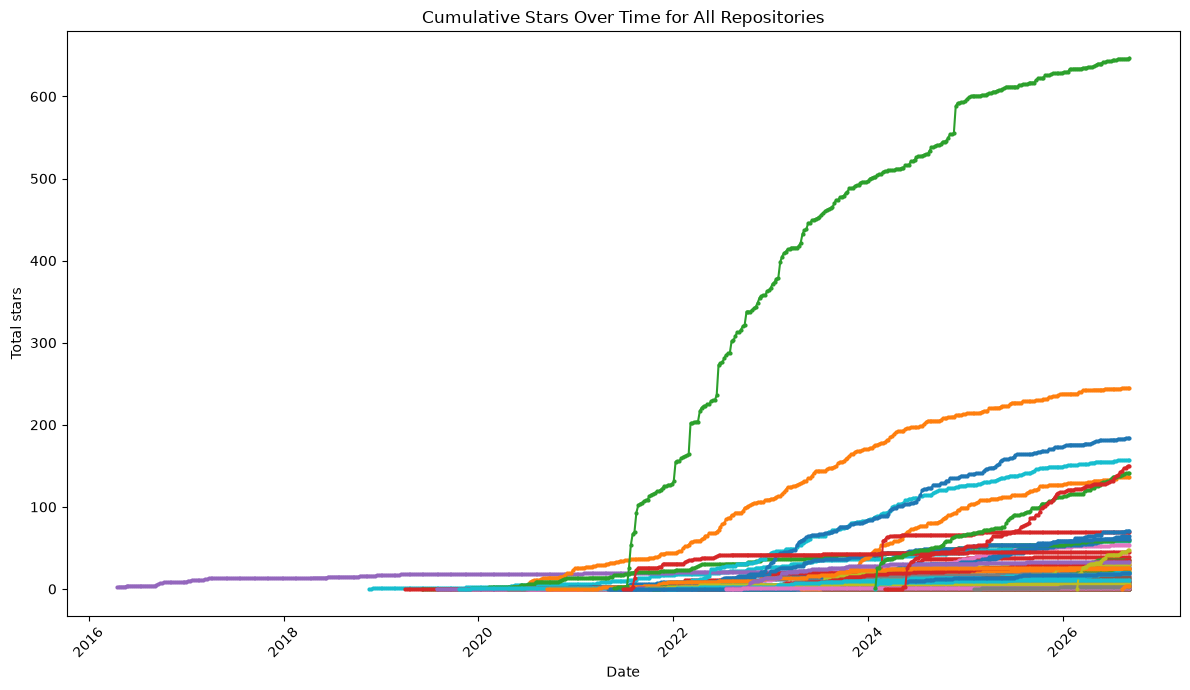

In [11]:
fig, ax = plt.subplots(figsize=(12, 7))

for repo_name, group in combined_df.groupby("repo_name"):
    ax.plot(group["date"], group["cumulative_stars"], marker="o", markersize=2, label=repo_name)

ax.set_title("Cumulative Stars Over Time for All Repositories")
ax.set_xlabel("Date")
ax.set_ylabel("Total stars")
ax.tick_params(axis="x", rotation=45)
#ax.legend(fontsize=6, ncol=2, loc="upper left", bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.show()

## Identify repository with highest total stars

We compute, for each repository, the final cumulative star count and sort to find the repository with the most total stars.

In [12]:
totals = combined_df.groupby("repo_name")["cumulative_stars"].max().sort_values(ascending=False)

display(totals.head(10).to_frame("total_stars"))

,total_stars
repo_name,
webis-de/small-text,647
clEsperanto/pyclesperanto_prototype,245
haesleinhuepf/stackview,184
haesleinhuepf/BioImageAnalysisNotebooks,157
weigertlab/trackastra,150
weigertlab/spotiflow,141
haesleinhuepf/bia-bob,137
haesleinhuepf/git-bob,71
haesleinhuepf/blablado,69


## Identify repository with strongest star uptake

We determine, for each repository, the maximum number of stars gained in a single week (the strongest observed burst of popularity).

In [13]:
max_weekly_gain = combined_df.groupby("repo_name")["total"].max().sort_values(ascending=False)

display(max_weekly_gain.head(10).to_frame("max_weekly_star_gain"))

,max_weekly_star_gain
repo_name,
haesleinhuepf/blablado,53
webis-de/small-text,38
ScaDS/vest,32
weigertlab/trackastra,24
weigertlab/spotiflow,24
weigertlab/muvit,18
ScaDS/BIDS-lecture-2024,12
webis-de/summary-explorer,10
tira-io/ir-experiment-platform,10


## Summary of most successful repositories

We print the top repository by total stars and the top repository by strongest single-week star uptake.

In [14]:
most_total_stars_repo = totals.idxmax()
most_total_stars_value = totals.max()

strongest_uptake_repo = max_weekly_gain.idxmax()
strongest_uptake_value = max_weekly_gain.max()

print(f"Repository with highest total stars: {most_total_stars_repo} ({most_total_stars_value} stars)")
print(f"Repository with strongest single-week star uptake: {strongest_uptake_repo} (+{strongest_uptake_value} stars in one week)")

Repository with highest total stars: webis-de/small-text (647 stars)
Repository with strongest single-week star uptake: haesleinhuepf/blablado (+53 stars in one week)
